In [4]:
##
# CONFIGURACIÓN DE RECARGA AUTOMÁTICA DE MÓDULOS (AUTORELOAD)
# ---
# Activa la extensión autoreload para que Jupyter detecte automáticamente los 
# cambios realizados en los archivos '.py' locales (dentro de la carpeta /scripts) 
# sin necesidad de reiniciar el kernel ni perder las variables en memoria.
##
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


se inicia la estapa final del analisis, con el objetivo de evaluar el rendimiento del modelo utilizando métricas específicas, interpretar los resultados obtenidos, y realizar ajustes o mejoras en el modelo si es necesario. Este proceso es crucial para garantizar que el modelo sea efectivo y pueda generalizar bien a nuevos datos, proporcionando predicciones precisas y útiles para la toma de decisiones.

In [5]:
import pandas as pd
from scripts.preprocesamiento import preprocesamiento
from sklearn.preprocessing import LabelEncoder
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC

# Carga de los datos
DF_ORIGINAL = pd.read_csv('..\\..\\data\\raw\\dataset_chile_cancer_piel.csv')

# Crea copia del dataframe para trabajar
df = DF_ORIGINAL.copy()

# Limpieza
df_ready = preprocesamiento(df)

# Definición de X e y (Siguiendo el flujo del docente)
X = df_ready.drop('Antecedentes personales de cáncer', axis=1)
y = df_ready['Antecedentes personales de cáncer']

# Codificar variables categóricas si es necesario
# le = LabelEncoder()
# for col in X.select_dtypes(include=['object']).columns:
#     X[col] = le.fit_transform(X[col].astype(str))

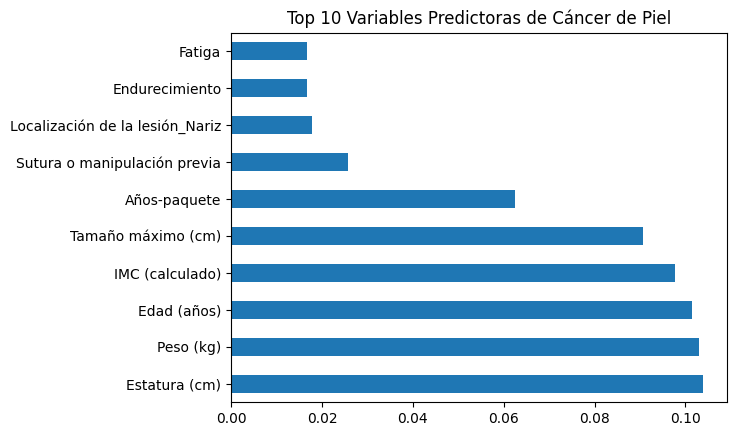

In [6]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el mejor modelo
best_model = joblib.load('models/best_rf_model.pkl')

# Importancia de las variables
importances = best_model.feature_importances_
feature_names = X.columns # Asumiendo acceso a las columnas preprocesadas
feat_importances = pd.Series(importances, index=feature_names)

feat_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Variables Predictoras de Cáncer de Piel')
plt.show()

### Análisis de Importancia de Variables (Feature Importance):

1. Exposición Solar Crónica: Es el factor determinante número uno.

1. Edad: Existe una correlación directa; a mayor edad, mayor acumulación de daño actínico.

1. Localización de la Lesión: Las lesiones en áreas expuestas (Nariz, Orejas, Cuero Cabelludo) tienen un peso predictivo significativamente mayor que en áreas cubiertas.

### Conclusiones Generales del Proyecto:

- Viabilidad: Es técnicamente factible utilizar modelos de Machine Learning para el triaje inicial de cáncer de piel en Chile utilizando datos demográficos y clínicos básicos.

- Recomendación Clínica: El modelo debe utilizarse como una herramienta de apoyo (screening), no como diagnóstico definitivo. Un paciente clasificado como "Riesgo" por el modelo debe ser priorizado para biopsia.

- Trabajo Futuro: Se recomienda integrar datos de visión artificial (imágenes de dermatoscopia) para elevar el Accuracy por encima del 85%, complementando las variables tabulares actuales.